# Sections 4.5 and 5.1–5.3, Appendix A — Evaluation

The statistics of the synthetic grids are computed from the samples (not part of the repository) from the command line:

```
python 05_evaluation/fitted_terms_tau.py
python 05_evaluation/evaluate_heldout.py          # ~1 h
python 05_evaluation/robustness_curves.py
python 05_evaluation/degree_distribution_samples.py
```

This notebook produces Figures 9 and 11–14 and Tables 6–9 from the stored results.

In [1]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().parent            # the notebook lives in <root>/<chapter folder>/
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

def run(script, *args):
    """Run one script of this repository and print its output."""
    out = subprocess.run([sys.executable, script, *args], capture_output=True, text=True)
    print(out.stdout[-3000:] or out.stderr[-3000:])

def show(name, width=900):
    display(Image(filename=f'figures/{name}', width=width))

## Figure 9 — base model vs. final model on the held-out statistics (Section 5.1)

country    n  base  final  final_better
     ES 1066  3.91   3.67          True
     DE  780  8.59   5.94          True
     IT  572  7.92   5.20          True
     PL  246  6.71   5.66          True
     CH  185  1.74   1.42          True
     RO  169  0.41   0.71         False
     BG  153  1.52   1.45          True
     PT  153  1.78   1.31          True
     AT  113  0.87   0.99         False
     CZ   67  0.78   0.58          True
     RS   51  0.34   0.39         False
     SK   47  0.41   0.73         False
     BA   39  0.58   0.27          True
     HR   24  1.20   1.07          True
     AL   23  0.46   0.58         False
final model better in 10 of 15 countries
stat
R_edge_attack    11
R_edge_random    10
assortativity     9
avg_path_len     11
betw_max          7
diameter          9
lambda2           7
Name: better, dtype: int64
|z|>2: final 27 base 33 of 105



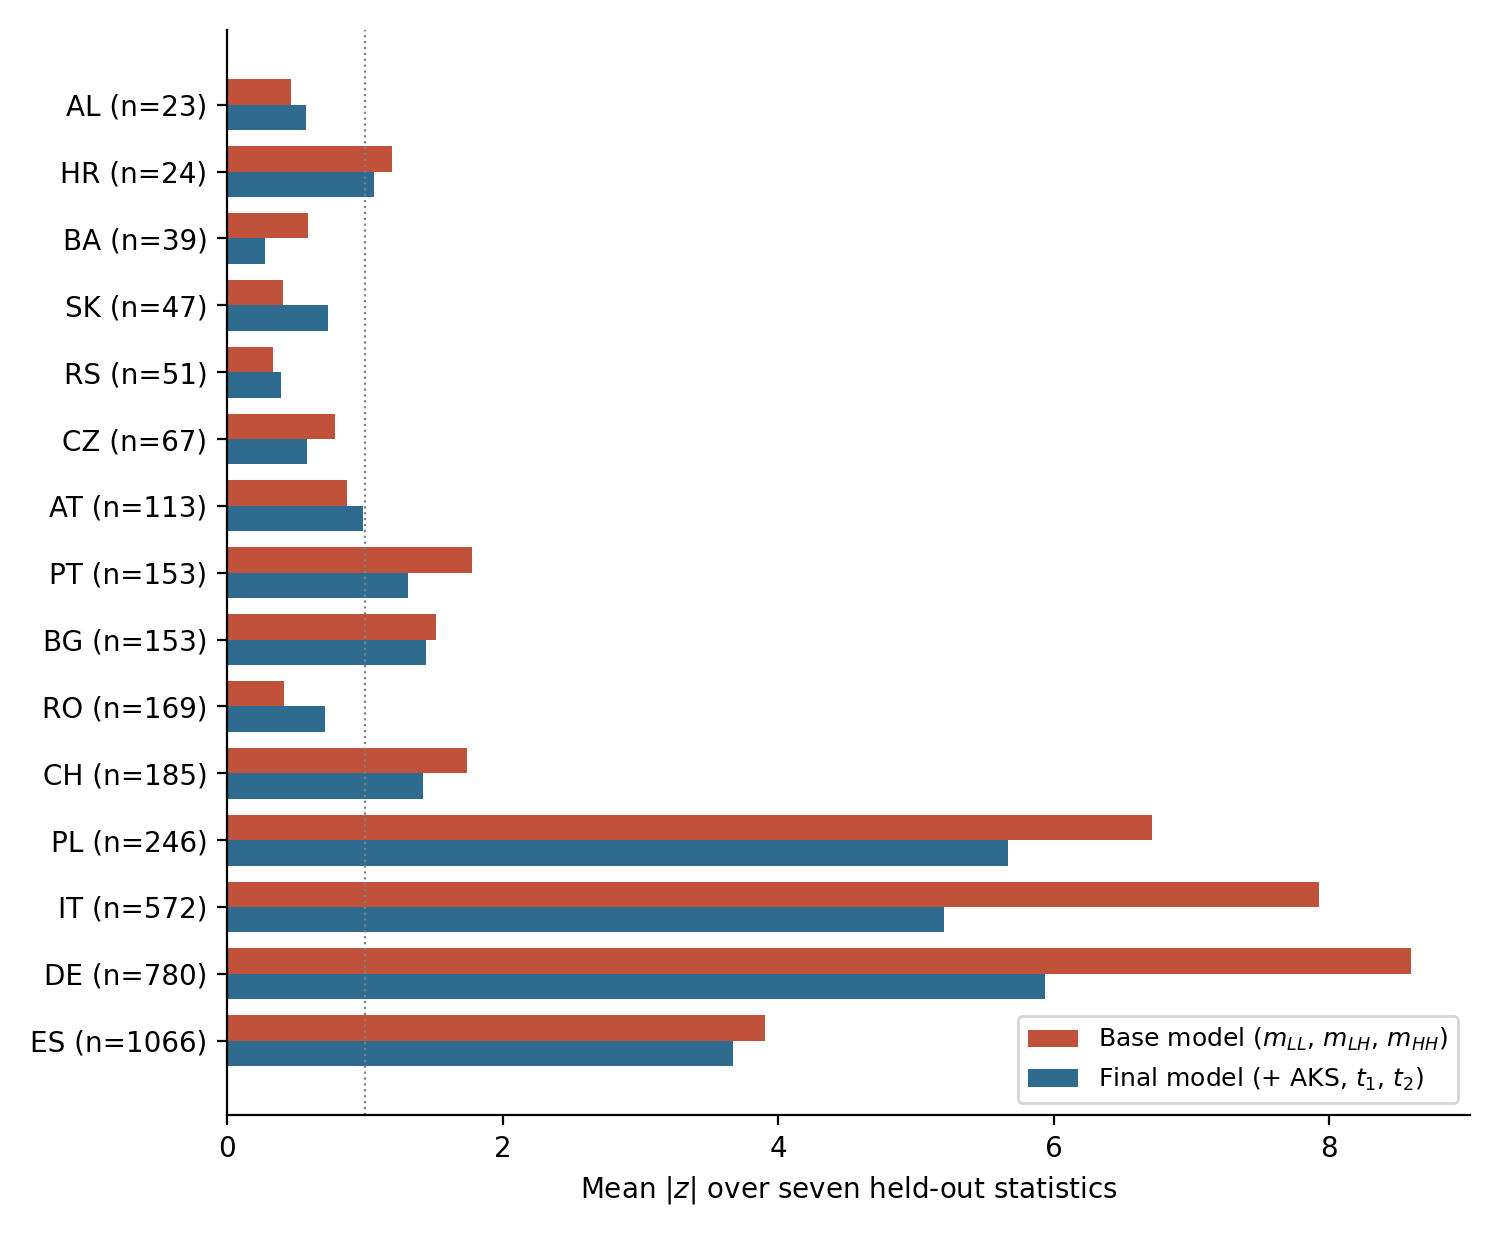

In [2]:
run('05_evaluation/fig9_base_vs_final.py'); show('fig_ablation_heldout_z.png', 600)

## Figure 11 — degree distribution of the synthetic grids (Section 5.2.2)

written



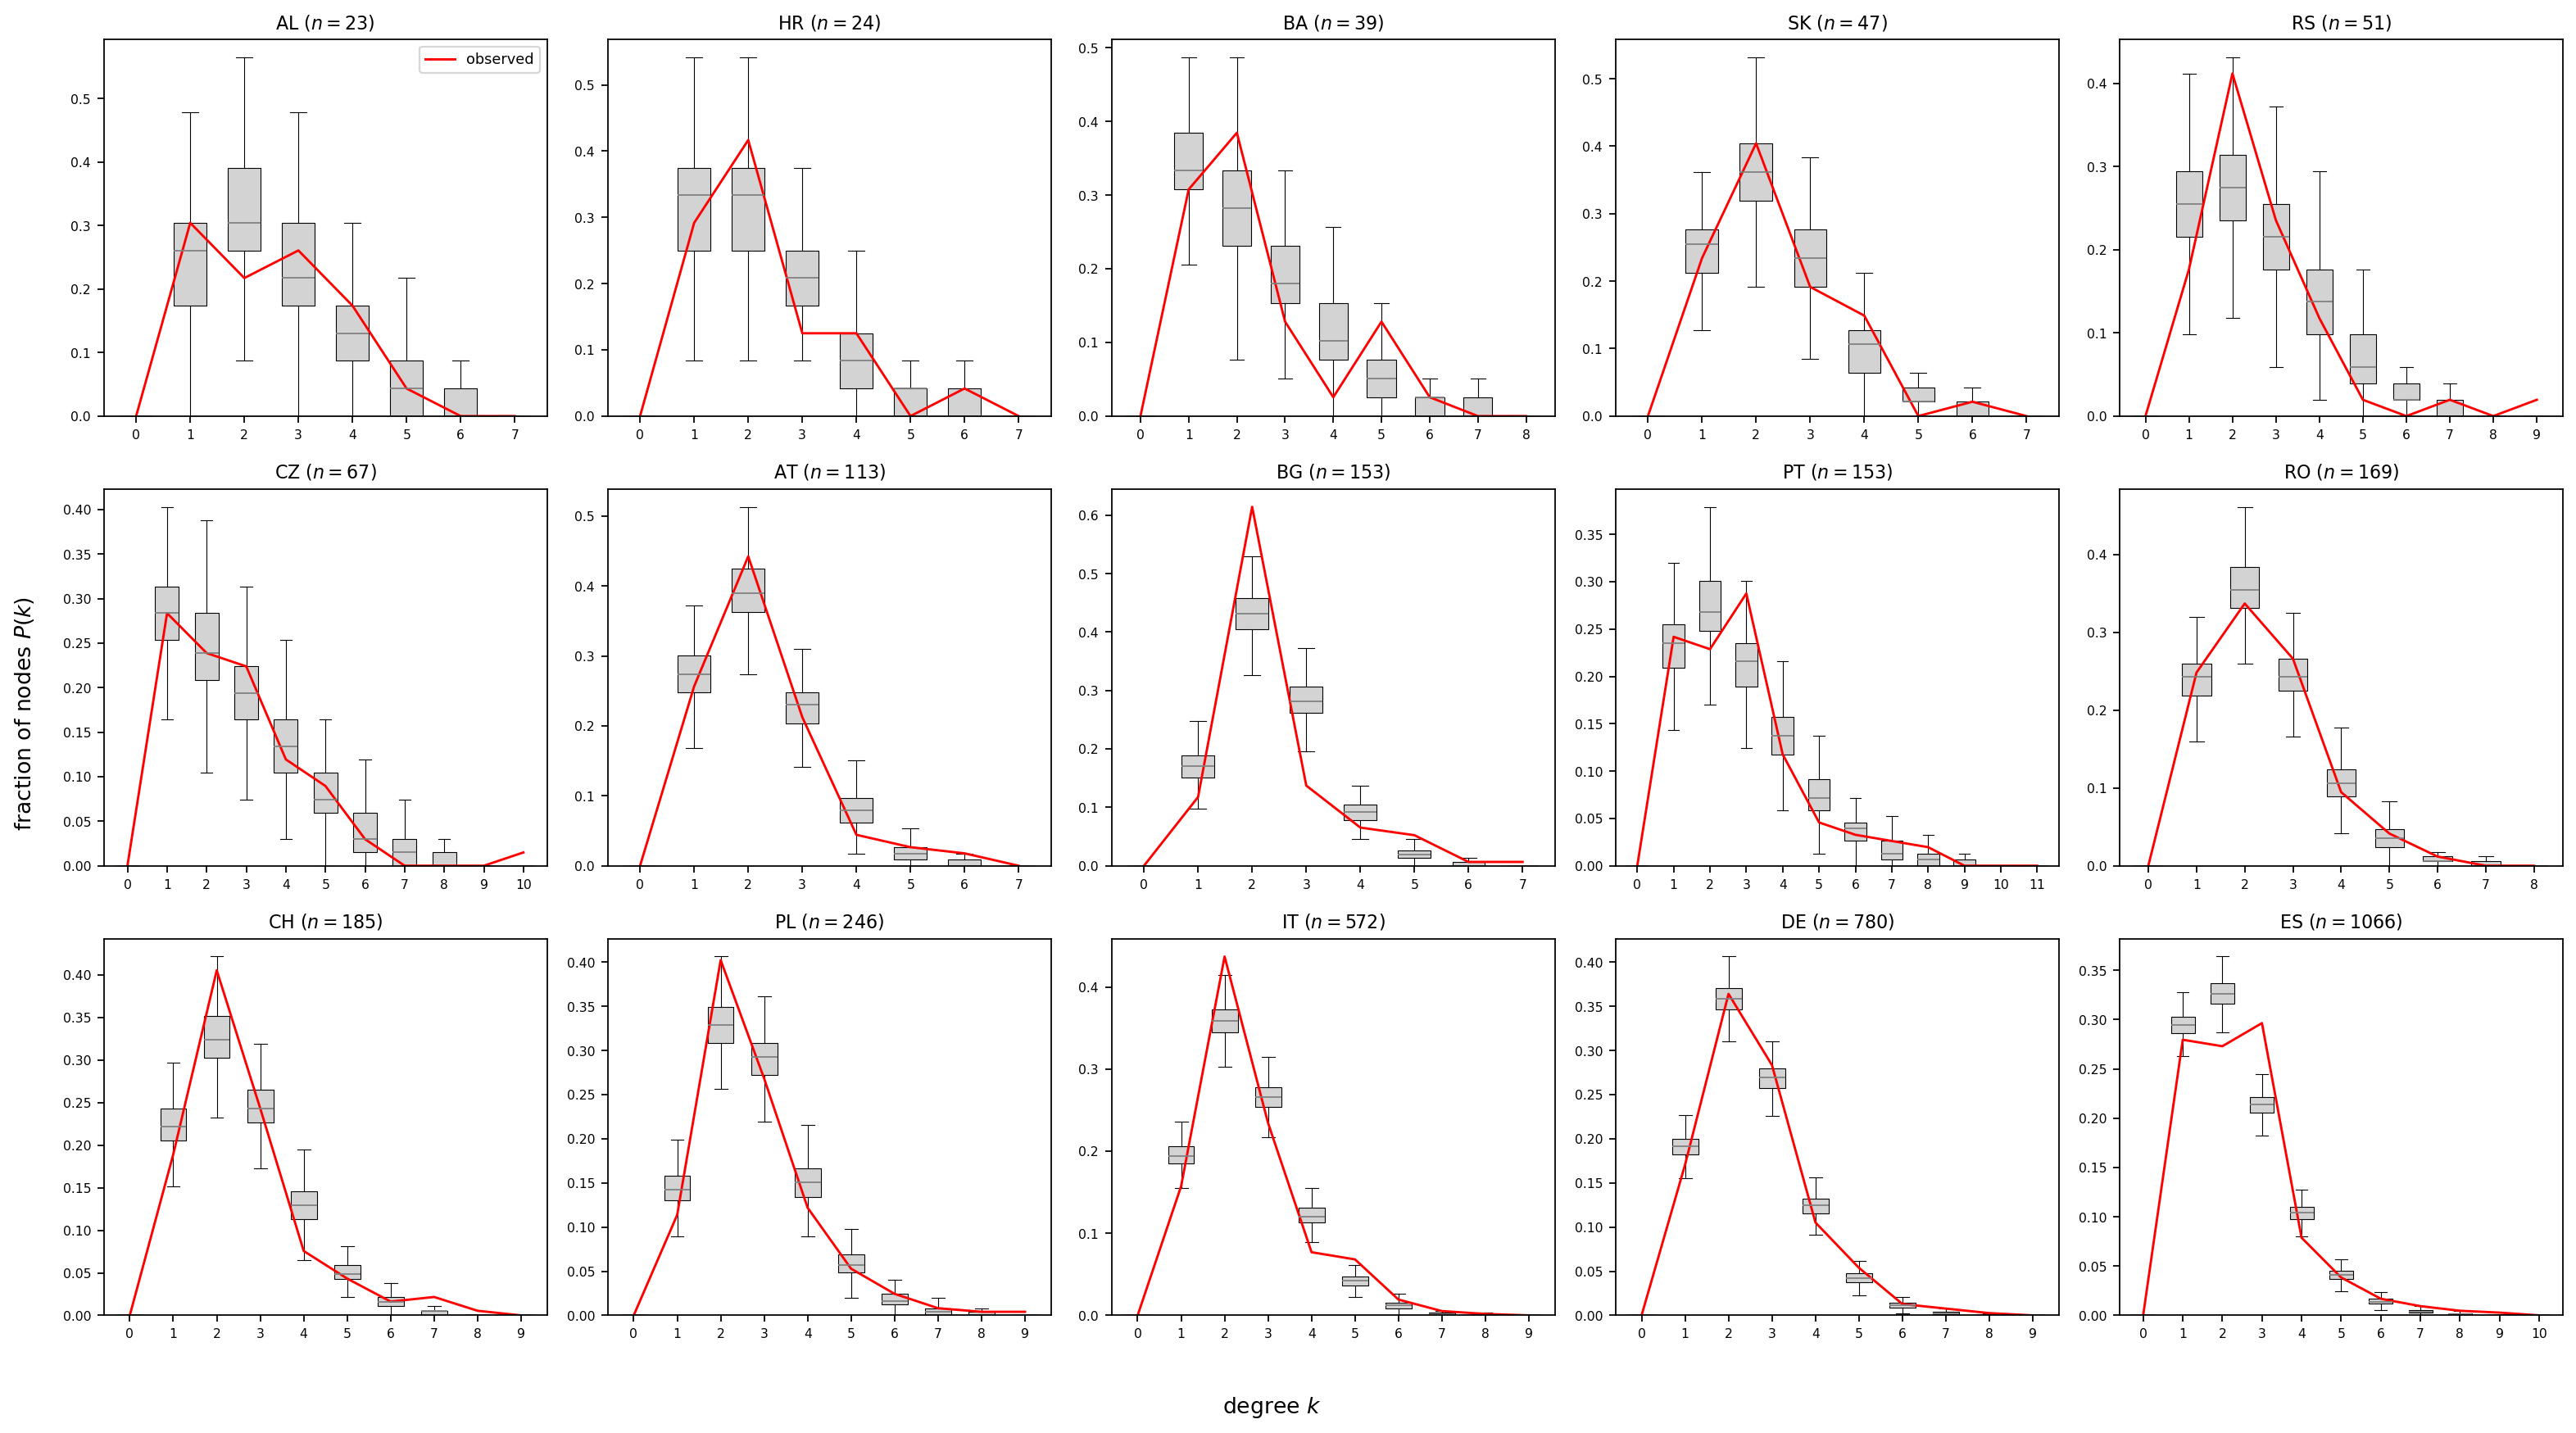

In [3]:
run('05_evaluation/fig11_degree_distribution_samples.py'); show('generalization_degree_gof.png')

## Figures 12 and 13 — z against network size, with Spearman correlations

avg_path_len    rho = -0.91, p = 2.9e-06
diameter        rho = -0.84, p = 8.88e-05
betw_max        rho = -0.89, p = 9.72e-06
lambda2         rho = +0.90, p = 4.13e-06
assortativity   rho = -0.41, p = 0.126
R_edge_random   rho = +0.64, p = 0.0105
R_edge_attack   rho = +0.65, p = 0.00913



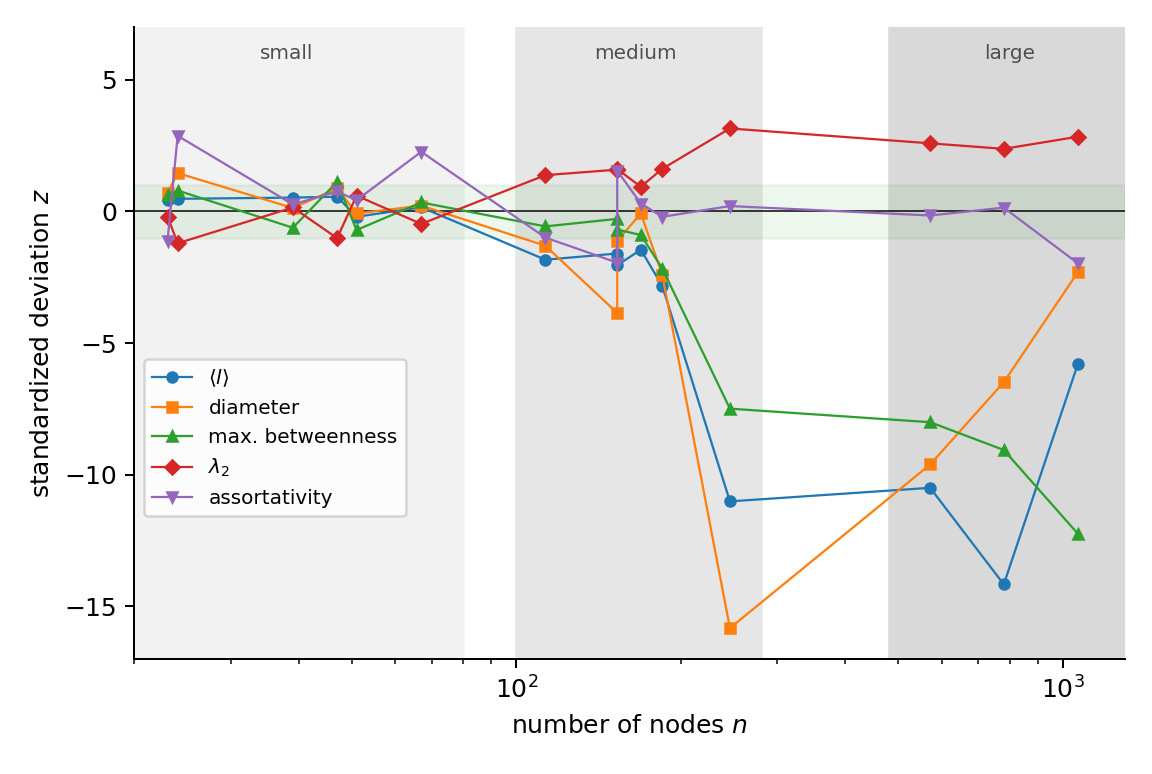

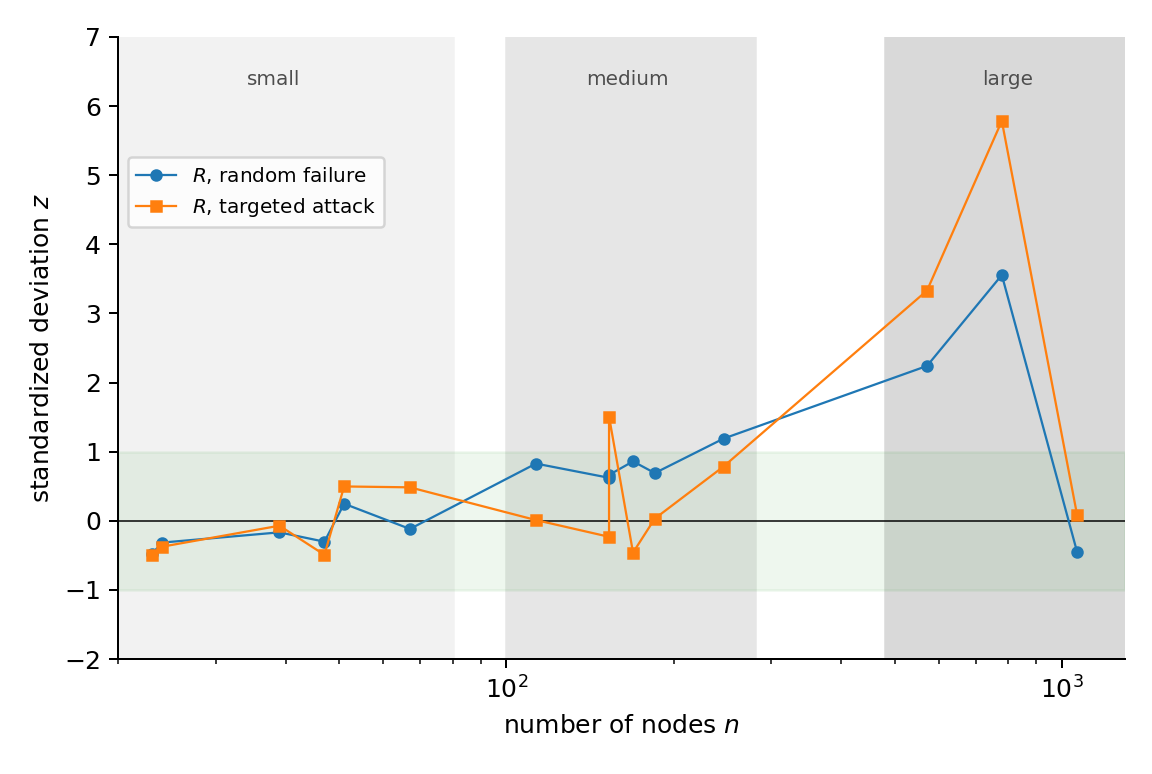

In [4]:
run('05_evaluation/fig12_13_z_vs_n.py'); show('fig_heldout_z_vs_n.png', 650); show('fig_robustness_z_vs_n.png', 650)

## Figure 14 — edge-removal curves of Bosnia and Herzegovina, Germany and Spain (Section 5.3)

DE, real grid under attack: largest drop at removal 158 of 1010 (f = 0.156): S 0.586 -> 0.296
ES, real grid under attack: largest drop at removal 277 of 1307 (f = 0.212): S 0.589 -> 0.305



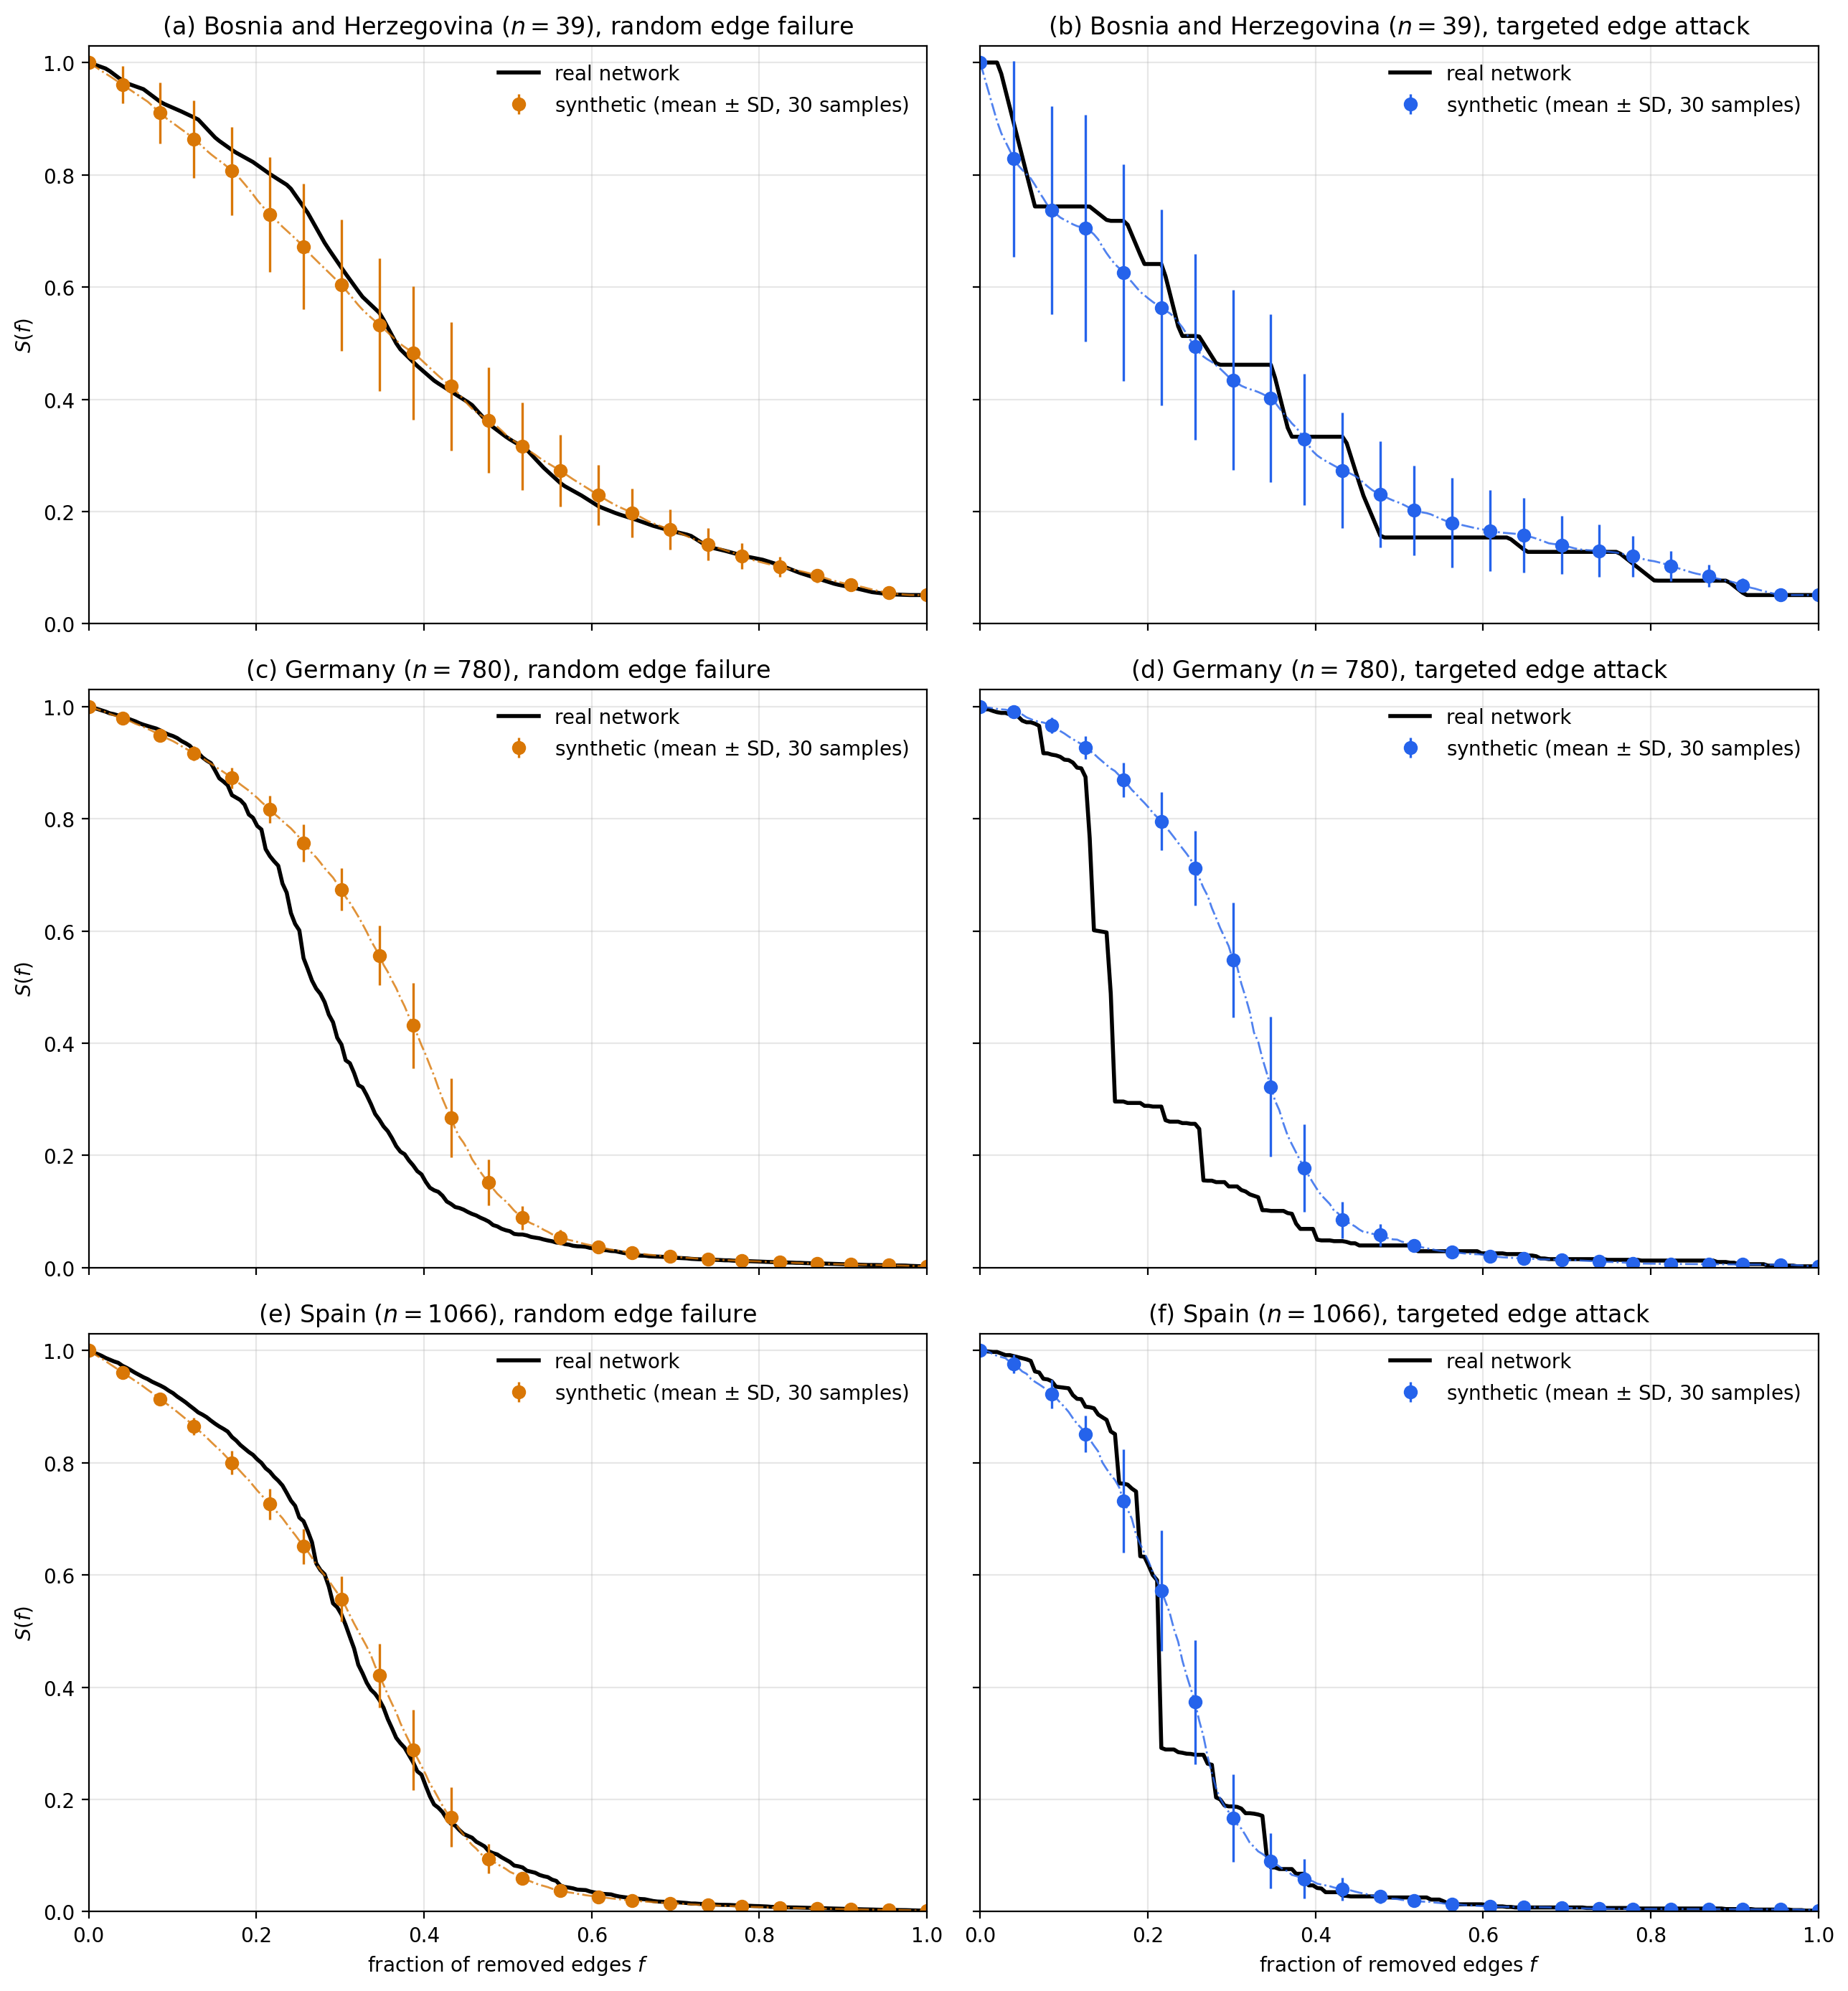

In [5]:
run('05_evaluation/fig14_robustness_curves.py'); show('robustness_edge_BA_DE_ES.png', 700)

## Tables 6–9 (Sections 5.2.2, 5.3 and Appendix A)

In [6]:
run('05_evaluation/tables_appendix.py')
tau = pd.read_csv('results/evaluation/tau_fitted_terms.csv')
tau.pivot(index='country', columns='term', values='tau_SD').loc[tau.country.unique()].round(2)

written table6_fitted_mixing, table7_fitted_other, table8_heldout_paths, table9_heldout_betweenness, table10_robustness



term,akstar,m_HH,m_LH,m_LL,t1,t2
country,,,,,,
AL,-0.10,-0.41,0.09,0.10,0.06,NaN
HR,-0.07,0.00,0.07,0.06,0.07,0.13
BA,-0.05,-0.10,0.17,0.08,0.10,0.13
SK,0.03,0.08,-0.02,0.05,0.12,0.25
RS,0.24,0.12,0.24,0.10,-0.98,-0.66
CZ,-0.08,0.06,0.16,0.04,0.08,0.09
AT,-0.01,0.06,-0.07,0.06,0.05,0.19
BG,-0.07,0.04,-0.05,0.10,0.09,0.16
PT,-0.07,0.08,-0.04,-0.02,-0.01,0.24


In [7]:
ho = pd.read_csv('results/evaluation/heldout_per_statistic.csv')
ho[ho.model == 'final'].pivot(index='country', columns='stat', values='z').loc[ho.country.unique()].round(1)

stat,R_edge_attack,R_edge_random,assortativity,avg_path_len,betw_max,betw_mean,diameter,lambda2
country,,,,,,,,
ES,0.1,-0.5,-2.0,-5.8,-12.2,-5.8,-2.3,2.8
DE,5.8,3.6,0.1,-14.2,-9.1,-14.2,-6.5,2.4
IT,3.3,2.2,-0.2,-10.5,-8.0,-10.5,-9.6,2.6
PL,0.8,1.2,0.2,-11.0,-7.5,-11.0,-15.8,3.1
CH,0.0,0.7,-0.2,-2.8,-2.2,-2.8,-2.4,1.6
RO,-0.5,0.9,0.3,-1.5,-0.9,-1.5,-0.1,0.9
PT,1.5,0.7,1.5,-2.0,-0.7,-2.0,-1.1,1.6
BG,-0.2,0.6,-1.9,-1.6,-0.3,-1.6,-3.9,1.6
AT,0.0,0.8,-1.0,-1.8,-0.6,-1.8,-1.3,1.4
